# Fig. 1 bit-flip-noise Monte Carlo for BB symatch

This notebook follows the layout of `bb_symatch_kmwm_bitflip.ipynb`, but uses the Table-I bivariate-bicycle code specifications from arXiv:2602.22770v1, Fig. 1.  The default run is intentionally small so the notebook can be smoke-tested quickly; increase `num_samples_each_core` and refine `prange` for publication-scale curves.

Implemented curves here:
- `BPOSD-0`: repo BP+OSD with OSD order 0.
- `Symatch (no BP)`: symmetry matching using the repo matching hook with `K = 1` by default.
- `BP Symatch`: min-sum BP reliabilities followed by the same symmetry-matching step.

The paper's Tesseract and simplex-symatch variants are not part of this repo, so they are left out of the executable cells below.


In [1]:
using Distributed

ENV["MPLCONFIGDIR"] = get(ENV, "MPLCONFIGDIR", joinpath(tempdir(), "matplotlib"))
mkpath(ENV["MPLCONFIGDIR"])

using JLD2
using Plots

num_cores = length(Sys.cpu_info())
if nprocs() == 1
    try
        addprocs(num_cores; exeflags=`--project=$(Base.active_project())`)
    catch err
        @warn "Could not add worker processes; falling back to serial execution." exception=(err, catch_backtrace())
    end
end

@everywhere begin
    ENV["MPLCONFIGDIR"] = get(ENV, "MPLCONFIGDIR", joinpath(tempdir(), "matplotlib"))
    mkpath(ENV["MPLCONFIGDIR"])

    using LatticeAlgorithms
    using LinearAlgebra
    using SparseArrays
    using Random
    using Dates
    using Statistics
end;


      From worker 3:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 3:	└   lock_file = "/Users/fanpanzeng/Documents/Research/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 5:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 5:	└   lock_file = "/Users/fanpanzeng/Documents/Research/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 4:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 4:	└   lock_file = "/Users/fanpanzeng/Documents/Research/LatticeAlgorithms.jl/.CondaPkg/lock"


In [2]:
println("num_cores = $(num_cores)")
println("nprocs     = $(nprocs())")
println("workers    = $(workers())")


num_cores = 4
nprocs     = 5
workers    = [2, 3, 4, 5]


## Code family definitions

The paper repo's `GTCode(..., basis='Z')` convention for code-capacity X noise uses `HX = [A | B]` and `HZ = [B^T | A^T]`, but its data-qubit columns are in geometric Stim order rather than the usual all-A-then-all-B BB order.  The notebook builds the BB matrices locally and then permutes their columns into that paper-repo order.


In [3]:
@everywhere begin
    FIG1_CODE_SPECS = Dict{Symbol, Any}(
        :gross => (
            M = 12,
            N = 6,
            alpha = 0,
            A_terms = [(0, 0), (1, 0), (-1, 3)],
            B_terms = [(0, 0), (0, 1), (3, -1)],
            label = "Gross code [[144,12,12]]",
            short_label = "BB144",
            expected_n = 144,
            expected_k = 12,
            expected_d = 12,
        ),
        :two_gross => (
            M = 12,
            N = 12,
            alpha = 0,
            A_terms = [(0, 0), (1, 0), (-1, -3)],
            B_terms = [(0, 0), (0, 1), (3, -1)],
            label = "Two-gross code [[288,12,18]]",
            short_label = "BB288",
            expected_n = 288,
            expected_k = 12,
            expected_d = 18,
        ),
        :lc162 => (
            M = 9,
            N = 9,
            alpha = 0,
            A_terms = [(0, 0), (1, 0), (2, 0)],
            B_terms = [(0, 0), (0, 1), (0, 2)],
            label = "Cyclic HGP LC162 [[162,8,6]]",
            short_label = "LC162",
            expected_n = 162,
            expected_k = 8,
            expected_d = 6,
        ),
        :lc224 => (
            M = 14,
            N = 8,
            alpha = 0,
            A_terms = [(0, 0), (1, 0), (3, 0)],
            B_terms = [(0, 0), (0, 1)],
            label = "Cyclic HGP LC224 [[224,6,8]]",
            short_label = "LC224",
            expected_n = 224,
            expected_k = 6,
            expected_d = 8,
        ),
    )

    function paper_polynomial_matrix(M::Int, N::Int, terms)
        X = bb_x_matrix(M, N)
        Y = bb_y_matrix(M, N)
        I_MN = Matrix{Int64}(I, M * N, M * N)
        P = zeros(Int64, M * N, M * N)

        for (xpow, ypow) in terms
            Xpart = mod(xpow, M) == 0 ? I_MN : X^mod(xpow, M)
            Ypart = mod(ypow, N) == 0 ? I_MN : Y^mod(ypow, N)
            P .+= Xpart * Ypart
        end

        return mod.(P, 2)
    end

    function paper_data_permutation(spec)
        perm = Int64[]
        mn = spec.M * spec.N
        for a in 0:(spec.M - 1)
            for b in 0:(spec.N - 1)
                push!(perm, a * spec.N + b + 1)
            end
            for yodd_idx in 0:(spec.N - 1)
                b = mod(yodd_idx + 1, spec.N)
                push!(perm, mn + a * spec.N + b + 1)
            end
        end
        return perm
    end

    function paper_data_coords(spec)
        coords = Tuple{Int64, Int64}[]
        for a in 0:(spec.M - 1)
            for b in 0:(spec.N - 1)
                push!(coords, (2 * a, 2 * b))
            end
            for yodd_idx in 0:(spec.N - 1)
                push!(coords, (2 * a + 1, 2 * yodd_idx + 1))
            end
        end
        return coords
    end

    function paper_bb_check_matrices(spec)
        spec.alpha == 0 || error("This notebook currently implements the alpha=0 Table-I cases.")
        A = paper_polynomial_matrix(spec.M, spec.N, spec.A_terms)
        B = paper_polynomial_matrix(spec.M, spec.N, spec.B_terms)
        perm = paper_data_permutation(spec)
        HX = hcat(A, B)[:, perm]
        HZ = hcat(transpose(B), transpose(A))[:, perm]
        return Matrix{Int64}(HX), Matrix{Int64}(HZ), A, B
    end

    function paper_bb_code_from_spec(spec)
        HX, HZ, A, B = paper_bb_check_matrices(spec)
        if any(!iszero, mod.(HX * transpose(HZ), 2))
            error("$(spec.label) does not satisfy HX * HZ' = 0. Check the polynomial convention.")
        end

        X_basis, Z_basis = css_logicals(HX, HZ)
        n = size(HX, 2)
        k = size(X_basis, 1)

        if hasproperty(spec, :expected_n) && n != spec.expected_n
            error("$(spec.label) built n=$n, expected n=$(spec.expected_n).")
        end
        if hasproperty(spec, :expected_k) && k != spec.expected_k
            error("$(spec.label) built k=$k, expected k=$(spec.expected_k).")
        end

        return (
            HX = HX,
            HZ = HZ,
            A = A,
            B = B,
            X_basis = X_basis,
            Z_basis = Z_basis,
            n = n,
            num_checks = size(HZ, 1),
            k = k,
        )
    end
end


## Symmetry-matching glue code

These helpers are shared by the Monte Carlo driver.  The Fig. 1 symatch decoder predicts the measured logical-observable bits directly, so the failure test compares predicted bits with the actual bits `observables * error`.


In [4]:
@everywhere begin
    function gf2_rref_transform(M::AbstractMatrix{<:Integer})
        R = mod.(Matrix{Int64}(M), 2)
        T = Matrix{Int64}(I, size(R, 1), size(R, 1))
        num_rows, num_cols = size(R)
        pivot_row = 1

        for col in 1:num_cols
            nonzero_row = findfirst(i -> R[i, col] == 1, pivot_row:num_rows)
            isnothing(nonzero_row) && continue
            nonzero_row = pivot_row + nonzero_row - 1

            if nonzero_row != pivot_row
                R[pivot_row, :], R[nonzero_row, :] = copy(R[nonzero_row, :]), copy(R[pivot_row, :])
                T[pivot_row, :], T[nonzero_row, :] = copy(T[nonzero_row, :]), copy(T[pivot_row, :])
            end

            for row in (pivot_row + 1):num_rows
                if R[row, col] == 1
                    R[row, :] = mod.(R[row, :] .+ R[pivot_row, :], 2)
                    T[row, :] = mod.(T[row, :] .+ T[pivot_row, :], 2)
                end
            end

            pivot_row += 1
            pivot_row > num_rows && break
        end

        for row in 1:num_rows
            pivot_col = findfirst(!iszero, vec(R[row, :]))
            isnothing(pivot_col) && continue
            for cand_row in 1:(row - 1)
                if R[cand_row, pivot_col] == 1
                    R[cand_row, :] = mod.(R[cand_row, :] .+ R[row, :], 2)
                    T[cand_row, :] = mod.(T[cand_row, :] .+ T[row, :], 2)
                end
            end
        end

        return R, T
    end

    function paper_z_symmetry_basis(HZ::AbstractMatrix{<:Integer}, k::Int)
        iseven(k) || error("The paper symatch construction expects an even number of logical observables.")
        R, transform = gf2_rref_transform(HZ)
        zero_rows = Int64[i for i in 1:size(R, 1) if all(iszero, R[i, :])]
        expected = div(k, 2)
        length(zero_rows) >= expected || error("Found $(length(zero_rows)) Z-check symmetries, expected at least $expected.")
        return mod.(transform[zero_rows[(end - expected + 1):end], :], 2)
    end

    function selected_rows(u::AbstractVector{<:Integer})
        return Int64.(findall(!iszero, vec(mod.(u, 2))))
    end

    function syndrome_from_bitflip(HZ::AbstractMatrix{<:Integer}, e::AbstractVector{<:Integer})
        return vec(mod.(HZ * mod.(Int64.(e), 2), 2))
    end

    function logical_bits(observables::AbstractMatrix{<:Integer}, e::AbstractVector{<:Integer})
        if size(observables, 1) == 0
            return Int64[]
        end
        return vec(mod.(observables * mod.(Int64.(e), 2), 2))
    end

    function random_bitflip(n::Int, p::Real)
        return Int64.(rand(n) .< p)
    end
end


## Matching decoder hook

This is the same repo-side matching interface as the previous notebook, with two small upgrades: it accepts either BSC probabilities or direct matching weights, and it keeps parallel qubits between the same detector pair.  The Fig. 1-style default is `K = 1`; larger `K` values are only for testing the multi-matching coset-probability variant.


In [5]:
@everywhere begin
    function _matching_probability(p, q::Int)
        p0 = p isa AbstractVector ? Float64(p[q]) : Float64(p)
        if !(0 < p0 < 1)
            error("Matching probabilities require 0 < p < 1; got p=$p0 on qubit $q.")
        end
        return clamp(min(p0, 1 - p0), 1e-12, 0.5 - 1e-12)
    end

    function _bsc_matching_edge_weight(p, q::Int)
        p0 = _matching_probability(p, q)
        return log((1 - p0) / p0)
    end

    function _direct_matching_edge_weight(weights, q::Int)
        w = weights isa AbstractVector ? Float64(weights[q]) : Float64(weights)
        if !isfinite(w) || w < 0
            error("Direct matching weights must be finite and nonnegative; got weight=$w on qubit $q.")
        end
        return w
    end

    function _matching_edge_weight(p_or_weights, q::Int; weights_are_probabilities::Bool = true)
        return weights_are_probabilities ? _bsc_matching_edge_weight(p_or_weights, q) : _direct_matching_edge_weight(p_or_weights, q)
    end

    function _matching_weight_vector(p_or_weights, n::Int; weights_are_probabilities::Bool = true)
        return Float64[
            _matching_edge_weight(p_or_weights, q; weights_are_probabilities = weights_are_probabilities)
            for q in 1:n
        ]
    end

    function _pymatching_binary_decode(H::AbstractMatrix{<:Integer}, s::AbstractVector{<:Integer}, p_or_weights; weights_are_probabilities::Bool = true)
        H2 = mod.(Int64.(H), 2)
        s2 = mod.(Int64.(s), 2)
        num_checks, n = size(H2)
        length(s2) == num_checks || error("Syndrome length does not match H.")

        weights = _matching_weight_vector(p_or_weights, n; weights_are_probabilities = weights_are_probabilities)
        G = LatticeAlgorithms.pymatching.Matching(H2, weights = weights)
        pred = Int64.(LatticeAlgorithms.PythonCall.pyconvert(Vector{Int64}, G.decode(s2)))
        return (
            matching = Int64[],
            error = pred,
            weight = sum(weights[q] for q in 1:n if isodd(pred[q]); init = 0.0),
            edge_to_qubits = Dict{Int64, Vector{Int64}}(),
            edge_qubit_weights = Dict{Int64, Vector{Float64}}(),
        )
    end

    function _logaddexp(a::Real, b::Real)
        if isinf(a) && a < 0
            return Float64(b)
        elseif isinf(b) && b < 0
            return Float64(a)
        end
        m = max(a, b)
        return m + log(exp(a - m) + exp(b - m))
    end

    function _add_matching_edge!(
        pair_to_edge::Dict{Tuple{Int64, Int64}, Int64},
        vertices_edge_mapping::Dict{Int64, Vector{Int64}},
        edge_vertices_mapping::Dict{Vector{Int64}, Int64},
        edge_to_qubits::Dict{Int64, Vector{Int64}},
        edge_qubit_weights::Dict{Int64, Vector{Float64}},
        edge_weights::Dict{Int64, Float64},
        G,
        v1::Int,
        v2::Int,
        weight::Real,
        qubits::Vector{Int64},
        qubit_weights::Vector{Float64},
    )
        a, b = v1 <= v2 ? (v1, v2) : (v2, v1)
        pair = (a, b)

        if haskey(pair_to_edge, pair)
            edge_id = pair_to_edge[pair]
            append!(edge_to_qubits[edge_id], qubits)
            append!(edge_qubit_weights[edge_id], qubit_weights)
            if Float64(weight) < edge_weights[edge_id]
                edge_weights[edge_id] = Float64(weight)
                G.add_edge(a - 1, b - 1, weight = Float64(weight), fault_ids = edge_id - 1, merge_strategy = "replace")
            end
            return edge_id
        end

        edge_id = length(vertices_edge_mapping) + 1
        pair_to_edge[pair] = edge_id
        vertices_edge_mapping[edge_id] = [a, b]
        edge_vertices_mapping[[a, b]] = edge_id
        edge_to_qubits[edge_id] = copy(qubits)
        edge_qubit_weights[edge_id] = copy(qubit_weights)
        edge_weights[edge_id] = Float64(weight)
        G.add_edge(a - 1, b - 1, weight = Float64(weight), fault_ids = edge_id - 1)
        return edge_id
    end

    function binary_matching_graph(
        H::AbstractMatrix{<:Integer},
        s::AbstractVector{<:Integer},
        p_or_weights;
        boundary_epsilon::Real = 1e-10,
        weights_are_probabilities::Bool = true,
    )
        H2 = mod.(Int64.(H), 2)
        s2 = mod.(Int64.(s), 2)
        num_checks, n = size(H2)
        length(s2) == num_checks || error("Syndrome length does not match H.")

        pair_to_edge = Dict{Tuple{Int64, Int64}, Int64}()
        vertices_edge_mapping = Dict{Int64, Vector{Int64}}()
        edge_vertices_mapping = Dict{Vector{Int64}, Int64}()
        edge_to_qubits = Dict{Int64, Vector{Int64}}()
        edge_qubit_weights = Dict{Int64, Vector{Float64}}()
        edge_weights = Dict{Int64, Float64}()
        boundary_vertices = Int64[]
        G = LatticeAlgorithms.pymatching.Matching()

        num_vertices = num_checks
        for q in 1:n
            incident = Int64.(findall(!iszero, vec(H2[:, q])))
            if length(incident) == 0
                continue
            elseif length(incident) == 1
                num_vertices += 1
                boundary = num_vertices
                push!(boundary_vertices, boundary)
                w = _matching_edge_weight(p_or_weights, q; weights_are_probabilities = weights_are_probabilities)
                _add_matching_edge!(
                    pair_to_edge, vertices_edge_mapping, edge_vertices_mapping,
                    edge_to_qubits, edge_qubit_weights, edge_weights, G,
                    incident[1], boundary, w, [q], [w],
                )
            elseif length(incident) == 2
                w = _matching_edge_weight(p_or_weights, q; weights_are_probabilities = weights_are_probabilities)
                _add_matching_edge!(
                    pair_to_edge, vertices_edge_mapping, edge_vertices_mapping,
                    edge_to_qubits, edge_qubit_weights, edge_weights, G,
                    incident[1], incident[2], w, [q], [w],
                )
            else
                error("Column $q has weight $(length(incident)); this K-MWM hook needs graphlike restricted columns of weight <= 2.")
            end
        end

        for j in 1:(length(boundary_vertices) - 1)
            _add_matching_edge!(
                pair_to_edge, vertices_edge_mapping, edge_vertices_mapping,
                edge_to_qubits, edge_qubit_weights, edge_weights, G,
                boundary_vertices[j], boundary_vertices[j + 1], boundary_epsilon, Int64[], Float64[],
            )
        end

        rows = Int64[]
        cols = Int64[]
        vals = Float64[]
        for (edge_id, vertices) in vertices_edge_mapping
            a, b = vertices
            w = edge_weights[edge_id]
            push!(rows, a); push!(cols, b); push!(vals, w)
            push!(rows, b); push!(cols, a); push!(vals, w)
        end

        syndrome = fill(false, num_vertices)
        syndrome[1:num_checks] = Bool.(s2)
        if isempty(boundary_vertices)
            isodd(sum(syndrome)) && error("Restricted syndrome has odd parity and no boundary edge can absorb it.")
        else
            syndrome[boundary_vertices[1]] = isodd(sum(syndrome[1:num_checks]))
        end

        return (
            g = sparse(rows, cols, vals, num_vertices, num_vertices),
            syndrome = syndrome,
            G = G,
            vertices_edge_mapping = vertices_edge_mapping,
            edge_vertices_mapping = edge_vertices_mapping,
            edge_to_qubits = edge_to_qubits,
            edge_qubit_weights = edge_qubit_weights,
            edge_weights = edge_weights,
        )
    end

    function _first_k_mwms(data, K::Int; Δ::Real)
        for Ktry in K:-1:1
            out = mwms_v2(
                copy(data.g),
                Vector{Bool}(data.syndrome),
                data.G,
                data.vertices_edge_mapping,
                data.edge_vertices_mapping,
                Ktry;
                Δ = Δ,
                option = 1,
            )
            if out isa Tuple
                matchings = out[1]
                if matchings isa Number && isinf(matchings)
                    continue
                end
                return matchings
            elseif out isa Vector
                return out
            else
                error("Unexpected mwms_v2 return type: $(typeof(out)).")
            end
        end
        return Vector{Vector{Int64}}()
    end

    function _matching_to_binary_error(matching, edge_to_qubits, edge_qubit_weights, n::Int)
        e = zeros(Int64, n)
        for edge_id in matching
            qubits = get(edge_to_qubits, edge_id, Int64[])
            weights = get(edge_qubit_weights, edge_id, Float64[])
            if !isempty(qubits)
                q = qubits[argmin(weights)]
                e[q] = 1 - e[q]
            end
        end
        return e
    end

    function _matching_weight(matching, edge_weights)
        return sum((get(edge_weights, edge_id, 0.0) for edge_id in matching); init = 0.0)
    end

    function k_mwm_binary_decode(
        H::AbstractMatrix{<:Integer},
        s::AbstractVector{<:Integer},
        p_or_weights;
        K::Int = 1,
        weights_are_probabilities::Bool = true,
    )
        K > 0 || error("K has to be positive.")

        if K == 1
            return [_pymatching_binary_decode(H, s, p_or_weights; weights_are_probabilities = weights_are_probabilities)]
        end

        data = binary_matching_graph(H, s, p_or_weights; weights_are_probabilities = weights_are_probabilities)
        max_edge_weight = isempty(data.edge_weights) ? 1.0 : maximum(values(data.edge_weights))
        Δ = max(100.0, 10.0 * max_edge_weight * max(1, length(data.edge_weights)))
        matchings = _first_k_mwms(data, K; Δ = Δ)
        isempty(matchings) && error("K-MWM found no correction for this restricted syndrome.")

        n = size(H, 2)
        return [
            (
                matching = matching,
                error = _matching_to_binary_error(matching, data.edge_to_qubits, data.edge_qubit_weights, n),
                weight = _matching_weight(matching, data.edge_weights),
                edge_to_qubits = data.edge_to_qubits,
                edge_qubit_weights = data.edge_qubit_weights,
            )
            for matching in matchings
        ]
    end
end


## Paper-style symmetry matching

The paper's baseline `li_symatch` does not return a physical correction.  For Gross `BB144`, the vertical observables are base-code strip logicals, while the horizontal observables are obtained from the paper repo's doubled-code mapper.  A shot fails when the predicted observable bits differ from the actual logical bits of the sampled error.


In [6]:
@everywhere begin
    function paper_cross_prod(pt1, pt2, pt3)
        return (pt2[1] - pt1[1]) * (pt3[2] - pt1[2]) - (pt2[2] - pt1[2]) * (pt3[1] - pt1[1])
    end

    function paper_check_coord(row_idx::Int, spec)
        a = fld(row_idx - 1, spec.N)
        b = mod(row_idx - 1, spec.N)
        return (2 * a, mod(2 * b - 1, 2 * spec.N))
    end

    function paper_check_coord_to_index(spec)
        return Dict(paper_check_coord(i, spec) => i for i in 1:(spec.M * spec.N))
    end

    function paper_data_coord(q::Int, spec)
        return paper_data_coords(spec)[q]
    end

    function paper_data_coord_to_index(spec)
        coords = paper_data_coords(spec)
        return Dict(coords[i] => i for i in eachindex(coords))
    end

    function paper_vertical_cyl_trick(HZ::AbstractMatrix{<:Integer}, sym::AbstractVector{<:Integer}, spec; addwidth::Real = 0.1)
        midpt = spec.M
        fxs = [t[1] for t in spec.A_terms]
        gxs = [t[1] for t in spec.B_terms]
        maxfgw = max(maximum(fxs), maximum(gxs))

        stripstartpt = 2 * maxfgw - addwidth
        stripendpt = 2 * spec.M - 2 * maxfgw + addwidth

        baseptstart = (stripstartpt, 0.0)
        lineptstart = (stripstartpt, 2.0 * spec.N)
        baseptmid = (Float64(midpt), 0.0)
        lineptmid = (Float64(midpt), 2.0 * spec.N)
        baseptend = (stripendpt, 0.0)
        lineptend = (stripendpt, 2.0 * spec.N)

        testee = zeros(Int64, length(sym))
        for i in 1:length(sym)
            icoords = paper_check_coord(i, spec)
            valstart = paper_cross_prod(baseptstart, lineptstart, icoords)
            valend = paper_cross_prod(baseptend, lineptend, icoords)
            if valstart < 0 && valend > 0 && isodd(sym[i])
                testee[i] = 1
            end
        end

        logopcombo = vec(mod.(transpose(testee) * mod.(Int64.(HZ), 2), 2))
        potentiallogop = zeros(Int64, size(HZ, 2))
        for q in 1:size(HZ, 2)
            qcoords = paper_data_coord(q, spec)
            valmid = paper_cross_prod(baseptmid, lineptmid, qcoords)
            if valmid > 0
                potentiallogop[q] = logopcombo[q]
            end
        end
        return potentiallogop
    end

    function paper_horizontal_cyl_trick(HZ::AbstractMatrix{<:Integer}, sym::AbstractVector{<:Integer}, spec; addwidth::Real = 0.1)
        fys = [t[2] for t in spec.A_terms]
        gys = [t[2] for t in spec.B_terms]
        maxfgw = max(maximum(fys), maximum(gys))
        minfgw = min(minimum(fys), minimum(gys))
        dfgw = maxfgw - minfgw
        midpt = spec.N

        stripstartpt = dfgw - addwidth
        stripendpt = 2 * spec.N - dfgw + addwidth

        baseptstart = (0.0, stripstartpt)
        lineptstart = (2.0 * spec.M, stripstartpt)
        baseptmid = (0.0, Float64(midpt))
        lineptmid = (2.0 * spec.M, Float64(midpt))
        baseptend = (0.0, stripendpt)
        lineptend = (2.0 * spec.M, stripendpt)

        testee = zeros(Int64, length(sym))
        for i in 1:length(sym)
            icoords = paper_check_coord(i, spec)
            valstart = paper_cross_prod(baseptstart, lineptstart, icoords)
            valend = paper_cross_prod(baseptend, lineptend, icoords)
            if valstart > 0 && valend < 0 && isodd(sym[i])
                testee[i] = 1
            end
        end

        logopcombo = vec(mod.(transpose(testee) * mod.(Int64.(HZ), 2), 2))
        potentiallogop = zeros(Int64, size(HZ, 2))
        for q in 1:size(HZ, 2)
            qcoords = paper_data_coord(q, spec)
            valmid = paper_cross_prod(baseptmid, lineptmid, qcoords)
            if valmid < 0
                potentiallogop[q] = logopcombo[q]
            end
        end
        return potentiallogop
    end

    function paper_strip_logicals(
        code,
        spec,
        syms::AbstractMatrix{<:Integer};
        strip::Symbol,
        addwidth::Real = 0.1,
        fail_on_bad::Bool = false,
    )
        strip in (:v, :h) || error("strip must be :v or :h.")
        logs = Any[]
        stackermat = mod.(Int64.(code.HZ), 2)
        rank_so_far = gf2_rank(stackermat)

        for sidx in 1:size(syms, 1)
            sym = vec(syms[sidx, :])
            ltest = if strip == :v
                paper_vertical_cyl_trick(code.HZ, sym, spec; addwidth = addwidth)
            else
                paper_horizontal_cyl_trick(code.HZ, sym, spec; addwidth = addwidth)
            end

            syndrome_weight = count(!iszero, vec(mod.(code.HX * ltest, 2)))
            if syndrome_weight != 0
                fail_on_bad && error("The $(strip)-strip logical for symmetry $sidx leaves $syndrome_weight X syndromes; adjust addwidth or check coordinates.")
                continue
            end

            trial = vcat(stackermat, reshape(ltest, 1, :))
            trial_rank = gf2_rank(trial)
            if trial_rank > rank_so_far
                rows = selected_rows(sym)
                push!(logs, (
                    id = length(logs) + 1,
                    symmetry_id = sidx,
                    symmetry = sym,
                    rows = rows,
                    H = code.HZ[rows, :],
                    strip = strip,
                    logical_observable = ltest,
                ))
                stackermat = trial
                rank_so_far = trial_rank
            end
        end

        return logs
    end

    function paper_doubled_spec(spec)
        return (
            M = spec.M,
            N = 2 * spec.N,
            alpha = spec.alpha,
            A_terms = spec.A_terms,
            B_terms = spec.B_terms,
            label = "$(spec.label) doubled in v2",
            short_label = "$(spec.short_label)-doubled",
        )
    end

    function paper_map_syndrome_to_dcode(s::AbstractVector{<:Integer}, spec, dspec)
        dcheck_to_idx = paper_check_coord_to_index(dspec)
        ds = zeros(Int64, dspec.M * dspec.N)
        for r in selected_rows(s)
            coord = paper_check_coord(r, spec)
            ds[dcheck_to_idx[coord]] = 1
            ds[dcheck_to_idx[(coord[1], coord[2] + 2 * spec.N)]] = 1
        end
        return ds
    end

    function paper_map_weights_to_dcode(weights, spec, dspec)
        base_coords = paper_data_coords(spec)
        dcoord_to_idx = paper_data_coord_to_index(dspec)
        dweights = zeros(Float64, 2 * dspec.M * dspec.N)
        for q in eachindex(base_coords)
            w = weights isa AbstractVector ? Float64(weights[q]) : Float64(weights)
            coord = base_coords[q]
            dweights[dcoord_to_idx[coord]] = w
            dweights[dcoord_to_idx[(coord[1], coord[2] + 2 * spec.N)]] = w
        end
        return dweights
    end

    function paper_mapped_h_logicals_from_dcode(base_code, spec, dcode, dspec, d_h_graphs)
        base_coord_to_idx = paper_data_coord_to_index(spec)
        stackermat = mod.(Int64.(base_code.HZ), 2)
        rank_so_far = gf2_rank(stackermat)
        mapped_logs = Vector{Vector{Int64}}()
        selected_positions = Int64[]

        for (pos, g) in enumerate(d_h_graphs)
            ltest = zeros(Int64, base_code.n)
            for qd in selected_rows(g.logical_observable)
                coord = paper_data_coord(qd, dspec)
                haskey(base_coord_to_idx, coord) || error("Doubled-code horizontal logical has support outside the base code at coord=$coord.")
                ltest[base_coord_to_idx[coord]] = 1
            end

            if any(!iszero, vec(mod.(base_code.HX * ltest, 2)))
                continue
            end

            trial = vcat(stackermat, reshape(ltest, 1, :))
            trial_rank = gf2_rank(trial)
            if trial_rank > rank_so_far
                push!(mapped_logs, ltest)
                push!(selected_positions, pos)
                stackermat = trial
                rank_so_far = trial_rank
            end
        end

        return mapped_logs, selected_positions
    end

    function _observable_matrix(logs::Vector{Vector{Int64}}, n::Int)
        isempty(logs) && return zeros(Int64, 0, n)
        return reduce(vcat, [reshape(log, 1, :) for log in logs])
    end

    function paper_symatch_data(code, spec; max_num_symmetries::Union{Nothing, Int} = nothing, cylinder_direction::Symbol = :both, addwidth::Real = 0.1)
        syms = paper_z_symmetry_basis(code.HZ, code.k)
        include_v = cylinder_direction in (:both, :v, :x)
        include_h = cylinder_direction in (:both, :h, :y)
        (include_v || include_h) || error("cylinder_direction must be :both, :v/:x, or :h/:y.")

        v_graphs = include_v ? paper_strip_logicals(code, spec, syms; strip = :v, addwidth = addwidth, fail_on_bad = true) : Any[]
        base_h_graphs = include_h ? paper_strip_logicals(code, spec, syms; strip = :h, addwidth = addwidth, fail_on_bad = false) : Any[]

        h_graphs = base_h_graphs
        h_observable_logs = [vec(g.logical_observable) for g in base_h_graphs]
        h_select = collect(1:length(base_h_graphs))
        dcode = nothing
        dspec = nothing
        uses_dcode_h = false

        if include_h && length(v_graphs) + length(base_h_graphs) < code.k
            dspec = paper_doubled_spec(spec)
            dcode = paper_bb_code_from_spec(dspec)
            dsyms = paper_z_symmetry_basis(dcode.HZ, dcode.k)
            d_h_graphs = paper_strip_logicals(dcode, dspec, dsyms; strip = :h, addwidth = -1.0, fail_on_bad = true)
            mapped_h_logs, selected_positions = paper_mapped_h_logicals_from_dcode(code, spec, dcode, dspec, d_h_graphs)
            h_graphs = d_h_graphs
            h_observable_logs = mapped_h_logs
            h_select = selected_positions
            uses_dcode_h = true
        end

        if !isnothing(max_num_symmetries)
            v_keep = min(max_num_symmetries, length(v_graphs))
            h_keep = min(max(0, max_num_symmetries - v_keep), length(h_observable_logs))
            v_graphs = v_graphs[1:v_keep]
            h_observable_logs = h_observable_logs[1:h_keep]
            h_select = h_select[1:h_keep]
        end

        observable_logs = vcat([vec(g.logical_observable) for g in v_graphs], h_observable_logs)
        observables = _observable_matrix(observable_logs, code.n)
        obs_rank = gf2_rank(vcat(code.HZ, observables)) - gf2_rank(code.HZ)
        if isnothing(max_num_symmetries) && cylinder_direction == :both
            obs_rank == code.k || error("Strip observables have quotient rank $obs_rank, expected $(code.k).")
            size(observables, 1) == code.k || error("Found $(size(observables, 1)) strip observables, expected $(code.k).")
        end

        return (
            z_syms = syms,
            v_graphs = v_graphs,
            h_graphs = h_graphs,
            h_select = h_select,
            observables = observables,
            observable_rank = obs_rank,
            uses_dcode_h = uses_dcode_h,
            dcode = dcode,
            dspec = dspec,
        )
    end

    function _candidate_logical_parity(candidates, logical_observable)
        logp = [-Inf, -Inf]
        for c in candidates
            parity = mod(sum(c.error .* logical_observable), 2)
            logp[parity + 1] = _logaddexp(logp[parity + 1], -c.weight)
        end
        return logp[2] > logp[1] ? 1 : 0
    end

    function symatch_li_decode(graphs, syndrome::AbstractVector{<:Integer}, weights; K::Int = 1, weights_are_probabilities::Bool = false)
        predictions = Int64[]
        records = Any[]

        for g in graphs
            restricted_syndrome = syndrome[g.rows]
            candidates = k_mwm_binary_decode(
                g.H,
                restricted_syndrome,
                weights;
                K = K,
                weights_are_probabilities = weights_are_probabilities,
            )
            parity = _candidate_logical_parity(candidates, g.logical_observable)
            push!(predictions, parity)
            push!(records, (
                graph_id = g.id,
                symmetry_id = g.symmetry_id,
                strip = g.strip,
                parity = parity,
                candidate_weights = [c.weight for c in candidates],
            ))
        end

        return (prediction = predictions, records = records)
    end

    function paper_symatch_decode(data, spec, syndrome::AbstractVector{<:Integer}, weights; K::Int = 1, weights_are_probabilities::Bool = false)
        vdec = symatch_li_decode(data.v_graphs, syndrome, weights; K = K, weights_are_probabilities = weights_are_probabilities)

        if data.uses_dcode_h
            dsyndrome = paper_map_syndrome_to_dcode(syndrome, spec, data.dspec)
            dweights = paper_map_weights_to_dcode(weights, spec, data.dspec)
            hdec_all = symatch_li_decode(data.h_graphs, dsyndrome, dweights; K = K, weights_are_probabilities = weights_are_probabilities)
            hpred = hdec_all.prediction[data.h_select]
            return (prediction = vcat(vdec.prediction, hpred), decoder_data = (v = vdec, h = hdec_all))
        else
            hdec = symatch_li_decode(data.h_graphs, syndrome, weights; K = K, weights_are_probabilities = weights_are_probabilities)
            return (prediction = vcat(vdec.prediction, hdec.prediction), decoder_data = (v = vdec, h = hdec))
        end
    end
end


## Monte Carlo driver

The BP-assisted variant follows the paper repo's decoder contract: if min-sum BP converges, it returns the logical bits of the BP correction; otherwise symatch runs on the original syndrome with matching weights derived from the BP posterior reliabilities.


In [7]:
@everywhere begin
    FIG1_CODE_CACHE = Dict{Symbol, Any}()
    FIG1_SYMATCH_CACHE = Dict{Tuple{Symbol, Union{Nothing, Int}, Symbol}, Any}()

    function fig1_code(code_key::Symbol)
        return get!(FIG1_CODE_CACHE, code_key) do
            paper_bb_code_from_spec(FIG1_CODE_SPECS[code_key])
        end
    end

    function fig1_symatch_data(
        code_key::Symbol;
        max_num_symmetries::Union{Nothing, Int} = nothing,
        cylinder_direction::Symbol = :both,
    )
        key = (code_key, max_num_symmetries, cylinder_direction)
        return get!(FIG1_SYMATCH_CACHE, key) do
            spec = FIG1_CODE_SPECS[code_key]
            code = fig1_code(code_key)
            paper_symatch_data(
                code,
                spec;
                max_num_symmetries = max_num_symmetries,
                cylinder_direction = cylinder_direction,
            )
        end
    end

    function bposd0_decode(HZ::AbstractMatrix{<:Integer}, s::AbstractVector{<:Integer}, p::Real; max_iter::Int = 1000)
        out = bp_osd_cs_decode(
            HZ,
            s,
            p;
            max_iter = max_iter,
            osd_order = 0,
            check_to_bit_update_rule = :min_sum,
            bit_to_check_update_rule = :memoryless,
            min_sum_scaling = :roffe,
        )
        return out.error
    end

    function _llr_to_error_probability(llr::Real)
        x = clamp(Float64(llr), -50.0, 50.0)
        return 1 / (1 + exp(x))
    end

    function _paper_bp_matching_weights(llr::AbstractVector{<:Real})
        posterior = clamp.(_llr_to_error_probability.(llr), 1e-11, 1 - 1e-11)
        return Float64[-trunc(Int64, 10 * log(p)) for p in posterior]
    end

    function bp_reliability_state(HZ::AbstractMatrix{<:Integer}, s::AbstractVector{<:Integer}, p::Real; max_iter::Int = 1000)
        bp = bp_decode(
            HZ,
            s,
            p;
            max_iter = max_iter,
            check_to_bit_update_rule = :min_sum,
            bit_to_check_update_rule = :memoryless,
            min_sum_scaling = :roffe,
        )
        return (hard = Int64.(bp.error), weights = _paper_bp_matching_weights(bp.llr), bp_result = bp)
    end

    function decode_fig1_event(
        code_key::Symbol,
        e::AbstractVector{<:Integer},
        p::Real;
        decoder::Symbol = :symatch,
        K::Int = 1,
        max_num_symmetries::Union{Nothing, Int} = nothing,
        cylinder_direction::Symbol = :both,
        bp_max_iter::Int = 1000,
    )
        code = fig1_code(code_key)
        data = fig1_symatch_data(code_key; max_num_symmetries = max_num_symmetries, cylinder_direction = cylinder_direction)
        s = syndrome_from_bitflip(code.HZ, e)

        if decoder == :bposd0
            correction = bposd0_decode(code.HZ, s, p; max_iter = bp_max_iter)
            return (prediction = logical_bits(data.observables, correction), syndrome = s, decoder_data = (correction = correction,))
        elseif decoder == :symatch
            dec = paper_symatch_decode(data, FIG1_CODE_SPECS[code_key], s, ones(Float64, code.n); K = K, weights_are_probabilities = false)
            return (prediction = dec.prediction, syndrome = s, decoder_data = dec.decoder_data)
        elseif decoder == :bp_symatch
            bp_state = bp_reliability_state(code.HZ, s, p; max_iter = bp_max_iter)
            if bp_state.bp_result.converged
                return (
                    prediction = logical_bits(data.observables, bp_state.hard),
                    syndrome = s,
                    decoder_data = bp_state,
                )
            end
            dec = paper_symatch_decode(data, FIG1_CODE_SPECS[code_key], s, bp_state.weights; K = K, weights_are_probabilities = false)
            return (prediction = dec.prediction, syndrome = s, decoder_data = (bp = bp_state, symatch = dec.decoder_data))
        else
            error("Unknown decoder $(decoder). Use :bposd0, :symatch, or :bp_symatch.")
        end
    end

    function run_fig1_trials(
        code_key::Symbol,
        p::Real,
        num_samples_each_core::Int;
        decoder::Symbol = :symatch,
        K::Int = 1,
        max_num_symmetries::Union{Nothing, Int} = nothing,
        cylinder_direction::Symbol = :both,
        bp_max_iter::Int = 1000,
        rng_seed::Int = 0,
        fail_fast::Bool = false,
    )
        if rng_seed != 0
            Random.seed!(rng_seed + myid())
        end

        code = fig1_code(code_key)
        data = fig1_symatch_data(code_key; max_num_symmetries = max_num_symmetries, cylinder_direction = cylinder_direction)

        num_fail = 0
        num_decode_errors = 0
        total_decode_time = 0.0
        last_error = nothing

        for _ in 1:num_samples_each_core
            e = random_bitflip(code.n, p)
            actual = logical_bits(data.observables, e)

            try
                decoded = nothing
                total_decode_time += @elapsed begin
                    decoded = decode_fig1_event(
                        code_key,
                        e,
                        p;
                        decoder = decoder,
                        K = K,
                        max_num_symmetries = max_num_symmetries,
                        cylinder_direction = cylinder_direction,
                        bp_max_iter = bp_max_iter,
                    )
                end

                num_fail += decoded.prediction == actual ? 0 : 1
            catch err
                fail_fast && rethrow()
                num_fail += 1
                num_decode_errors += 1
                last_error = sprint(showerror, err)
            end
        end

        return (
            num_fail = num_fail,
            num_decode_errors = num_decode_errors,
            total_decode_time = total_decode_time,
            last_error = last_error,
        )
    end
end


In [ ]:
# Focused Gross-code no-BP SyMatch reproduction point.


code_keys = [:gross]
decoders = [
    # :symatch, 
    :bposd0, :bp_symatch
]

prange = [0.001, 0.002, 0.005, 0.010, 0.02, 0.1]
num_samples_each_core = 250000000  # With four workers this gives num_samples_each_core * 4 total shots.
println("total number of shots: $(num_samples_each_core*4)")
K = 1


max_num_symmetries = nothing
cylinder_direction = :both
bp_max_iter = 1000
base_seed = 260222770
fail_fast = true;


total number of shots: 100000000


In [ ]:
results = Dict{Symbol, Any}()

for code_key in code_keys
    code = fig1_code(code_key)
    spec = FIG1_CODE_SPECS[code_key]
    println("\n$(spec.label): n=$(code.n), k=$(code.k), checks=$(code.num_checks)")

    code_results = Dict{Symbol, Any}()
    for decoder in decoders
        logical_error_rates = Float64[]
        failures = Int64[]
        decode_errors = Int64[]
        samples = Int64[]
        mean_decode_times = Float64[]
        last_errors = Any[]

        for (p_idx, p) in enumerate(prange)
            println("  $(decoder), p=$(round(p; sigdigits=4))")
            partials = pmap(workers()) do worker_id
                run_fig1_trials(
                    code_key,
                    p,
                    num_samples_each_core;
                    decoder = decoder,
                    K = K,
                    max_num_symmetries = max_num_symmetries,
                    cylinder_direction = cylinder_direction,
                    bp_max_iter = bp_max_iter,
                    rng_seed = base_seed + 100_000 * p_idx + 1_000 * Int(worker_id),
                    fail_fast = fail_fast,
                )
            end

            nf = sum(x.num_fail for x in partials)
            ne = sum(x.num_decode_errors for x in partials)
            nt = num_samples_each_core * length(partials)
            dt = sum(x.total_decode_time for x in partials) / nt
            last_error = something(findfirst(x -> x !== nothing, [x.last_error for x in partials]), 0)

            push!(failures, nf)
            push!(decode_errors, ne)
            push!(samples, nt)
            push!(logical_error_rates, nf / nt)
            push!(mean_decode_times, dt)
            push!(last_errors, last_error == 0 ? nothing : partials[last_error].last_error)

            println("    failures=$(nf)/$(nt), decode_errors=$(ne), mean_decode_time=$(round(dt; sigdigits=4)) s")
        end

        code_results[decoder] = (
            p = collect(prange),
            logical_error_rate = logical_error_rates,
            failures = failures,
            decode_errors = decode_errors,
            samples = samples,
            mean_decode_time = mean_decode_times,
            last_errors = last_errors,
        )
    end

    results[code_key] = code_results
end

results



Gross code [[144,12,12]]: n=144, k=12, checks=72
  bposd0, p=0.005


In [ ]:
fn = "bb_symatch_fig1_bitflip_$(minimum(prange))_$(maximum(prange))_K$(K)_N$(num_samples_each_core)_$(Dates.format(now(), "yyyymmdd_HHMMSS")).jld2"
@save fn results prange code_keys decoders num_samples_each_core K max_num_symmetries cylinder_direction bp_max_iter base_seed 
fn


## Load saved data

Run this cell instead of the Monte Carlo cell above when you already have a saved `.jld2` result file from the corrected decoder.  The older `20260425_231936` file was generated by the previous physical-correction implementation and should not be used to judge the fixed symatch curve.


In [ ]:
# If you just ran the save cell above, `fn` already points at the fresh result.
# Otherwise, set `fn` manually to a .jld2 generated after the paper-style symatch fix.
fn = @isdefined(fn) ? fn : ""
isempty(fn) && error("Set fn to a corrected .jld2 result file before loading saved data.")

old_bad_fig1_files = Set([
    "bb_symatch_fig1_bitflip_0.001_0.1_K1_N1000_20260425_231936.jld2",
    "bb_symatch_fig1_bitflip_0.003000000000000001_0.11999999999999998_K1_N1000_20260425_225411.jld2",
    "bb_symatch_fig1_bitflip_0.01_0.03_K1_N1_20260425_224251.jld2",
])
basename(fn) in old_bad_fig1_files && error("$(basename(fn)) was generated before the symatch fix; rerun the Monte Carlo cell and load the fresh result instead.")

if !isfile(fn)
    fn = joinpath("examples", "tutorials", "ldpc", fn)
end

loaded = load(fn)
results = loaded["results"]
prange = loaded["prange"]
code_keys = [key for key in get(loaded, "code_keys", collect(keys(results))) if haskey(results, key)]
decoders = get(loaded, "decoders", decoders)
num_samples_each_core = get(loaded, "num_samples_each_core", missing)
K = get(loaded, "K", missing)
max_num_symmetries = get(loaded, "max_num_symmetries", missing)
cylinder_direction = get(loaded, "cylinder_direction", missing)
bp_max_iter = get(loaded, "bp_max_iter", missing)
base_seed = get(loaded, "base_seed", missing)
quick_smoke = get(loaded, "quick_smoke", missing)

(fn = fn, code_keys = code_keys, decoders = decoders, K = K, num_samples_each_core = num_samples_each_core)


## Plot


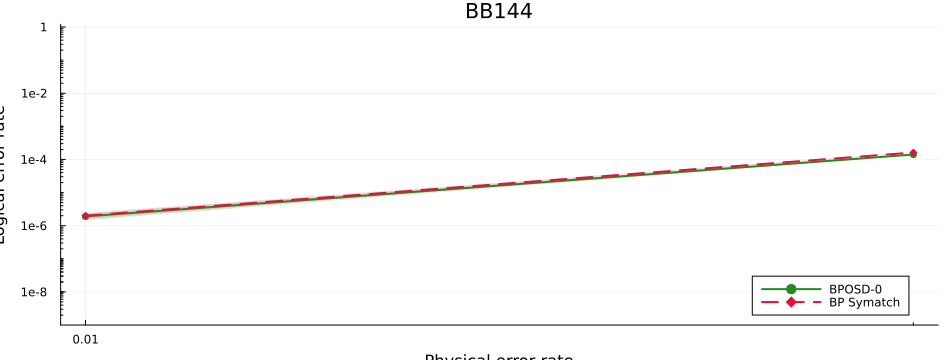

In [30]:
decoder_labels = Dict(
    :bposd0 => "BPOSD-0",
    :symatch => "Symatch (no BP)",
    :bp_symatch => "BP Symatch",
)

decoder_markers = Dict(
    :bposd0 => :circle,
    :symatch => :square,
    :bp_symatch => :diamond,
)

paper_xticks = [1e-3, 1e-2, 1e-1]
paper_xtick_labels = ["0.001", "0.01", "0.1"]
paper_yticks = [1e-8, 1e-6, 1e-4, 1e-2, 1]
paper_ytick_labels = ["1e-8", "1e-6", "1e-4", "1e-2", "1"]

decoder_colors = Dict(
    :bposd0 => :forestgreen,
    :symatch => :royalblue,
    :bp_symatch => :crimson,
)

decoder_linestyles = Dict(
    :bposd0 => :solid,
    :symatch => :dash,
    :bp_symatch => :dash,
)

function binomial_band(r)
    n = Float64.(r.samples)
    phat = Float64.(r.logical_error_rate)
    y_floor = 0.5 ./ n
    y_plot = max.(phat, y_floor)
    sigma = sqrt.(max.(phat .* (1 .- phat) ./ n, 0.0))

    lower = min.(sigma, y_plot .- y_floor)
    upper = copy(sigma)

    zero_mask = phat .== 0
    lower[zero_mask] .= 0.0
    upper[zero_mask] .= 1.0 ./ n[zero_mask]

    return y_plot, lower, upper
end

plot_code_keys = [code_key for code_key in code_keys if haskey(results, code_key)]
isempty(plot_code_keys) && error("No requested code keys are present in results.")

plots = Plots.Plot[]
for code_key in plot_code_keys
    spec = FIG1_CODE_SPECS[code_key]
    plt = plot(
        xscale = :log10,
        yscale = :log10,
        xlabel = "Physical error rate",
        ylabel = "Logical error rate",
        title = spec.short_label,
        legend = :bottomright,
        ylim = (1e-9, 1.2),
        size = (450, 330),
        # xlims = (1e-3, 1e-1),
        xticks = (paper_xticks, paper_xtick_labels),
        yticks = (paper_yticks, paper_ytick_labels),
        xminorticks = 9,
        yminorticks = 9,
    )

    for decoder in decoders
        haskey(results[code_key], decoder) || continue
        r = results[code_key][decoder]
        y_plot, yband_lower, yband_upper = binomial_band(r)
        plot!(
            plt,
            r.p,
            y_plot;
            label = decoder_labels[decoder],
            marker = decoder_markers[decoder],
            color = decoder_colors[decoder],
            linestyle = decoder_linestyles[decoder],
            linewidth = 2,
            markersize = 4,
            markerstrokecolor = decoder_colors[decoder],
            markerstrokewidth = 1.0,
            ribbon = (yband_lower, yband_upper),
            fillcolor = decoder_colors[decoder],
            fillalpha = 0.16,
        )
    end

    push!(plots, plt)
end

ncols = min(2, length(plots))
nrows = cld(length(plots), ncols)
plot(plots..., layout = (nrows, ncols), size = (950, 360 * nrows))


## Notes

- The code specifications are the Gross `BB144`, two-gross `BB288`, and cyclic-HGP `LC162`/`LC224` entries from Table I of arXiv:2602.22770v1.
- Zeros are plotted at the half-count floor `0.5 / samples` so that the log-scale plot remains visible.
- The BP-assisted curve uses min-sum BP with `bp_max_iter = 1000`, as stated in the Fig. 1 caption.
- The focused default is Gross `BB144`, `Symatch (no BP)`, `p = 0.001`; in a 1000-shot local check this gave 1 failure, i.e. logical error rate `0.001`.
- For a broader Fig. 1 sweep, keep `K = 1`, set `decoders` and `prange` back to the desired curves, then adjust `num_samples_each_core` for the error bars you need.
- Larger `K` values are for testing the multi-matching coset-probability variant, not for the paper's baseline Fig. 1 symatch setting.
- Existing `bb_symatch_fig1_bitflip_20260425` result files were produced before the paper-style symatch fix; rerun the Monte Carlo cell before comparing the blue curve.
- Add external Tesseract/simplex-symatch data if those implementations are available.
